<a href="https://colab.research.google.com/github/RohanCoderiiitb/AIT-511-Machine-Learning-Assignment-1/blob/main/problem_statement_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing Necessary Packages

In [1]:
!pip install --upgrade pip
!pip install numpy pandas matplotlib seaborn scikit-learn torch jupyter ipykernel

In [2]:
import numpy, pandas, matplotlib, seaborn, sklearn, torch
print("numpy       :", numpy.__version__)
print("pandas      :", pandas.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", seaborn.__version__)
print("scikit-learn:", sklearn.__version__)
print("torch       :", torch.__version__)

numpy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.10.0
seaborn     : 0.13.2
scikit-learn: 1.6.1
torch       : 2.11.0+cpu


# Exploratory Data Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.preprocessing import StandardScaler

In [6]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

train_df = pd.read_csv('BT2024238_train_var2.csv')
test_df  = pd.read_csv('BT2024238_test_var2.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

train_df.head()

Train shape: (1000, 4)
Test shape : (1000, 3)

Train columns: ['x1', 'x2', 'x3', 'y']
Test columns : ['x1', 'x2', 'x3']


,x1,x2,x3,y
0,-0.411757,-0.525925,-0.471073,1.042782
1,-0.502641,1.000000,0.218567,5.578685
2,-0.064827,-0.777178,-0.262487,2.467874
3,-1.000000,0.115325,0.349572,-4.884211
4,0.690122,0.370810,-1.000000,-0.451483


In [7]:
features = ['x1', 'x2', 'x3']

print("=== Data types and non-null counts ===")
train_df.info()

print("\n=== Summary statistics (train) ===")
display(train_df.describe().T)

print("\n=== Missing values (NaN) ===")
print("Train:\n", train_df.isna().sum())
print("Test:\n", test_df.isna().sum())

print("\n=== Duplicate rows ===")
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates :", test_df.duplicated().sum())

print("\n=== Values stuck at the boundary (disguised missing, or clipping?) ===")
for name, df_ in [('train', train_df), ('test', test_df)]:
    print(name)
    for col in features:
        lo = (df_[col] == -1.0).mean()
        hi = (df_[col] ==  1.0).mean()
        print(f"  {col}: at -1: {lo:.1%} | at +1: {hi:.1%}")

=== Data types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1000 non-null   float64
 1   x2      1000 non-null   float64
 2   x3      1000 non-null   float64
 3   y       1000 non-null   float64
dtypes: float64(4)
memory usage: 31.4 KB

=== Summary statistics (train) ===


,count,mean,std,min,25%,50%,75%,max
x1,1000.0,0.004519,0.680431,-1.000000,-0.579798,-0.017747,0.620265,1.000000
x2,1000.0,-0.016606,0.673323,-1.000000,-0.605482,-0.045641,0.556037,1.000000
x3,1000.0,-0.014581,0.671754,-1.000000,-0.582138,-0.008135,0.553517,1.000000
y,1000.0,2.319322,6.394483,-29.328352,-0.351835,1.323846,5.155851,38.966397



=== Missing values (NaN) ===
Train:
 x1    0
x2    0
x3    0
y     0
dtype: int64
Test:
 x1    0
x2    0
x3    0
dtype: int64

=== Duplicate rows ===
Train duplicates: 0
Test duplicates : 4

=== Values stuck at the boundary (disguised missing, or clipping?) ===
train
  x1: at -1: 13.1% | at +1: 13.1%
  x2: at -1: 10.7% | at +1: 12.9%
  x3: at -1: 13.1% | at +1: 13.0%
test
  x1: at -1: 12.3% | at +1: 12.9%
  x2: at -1: 11.8% | at +1: 11.8%
  x3: at -1: 11.4% | at +1: 11.9%


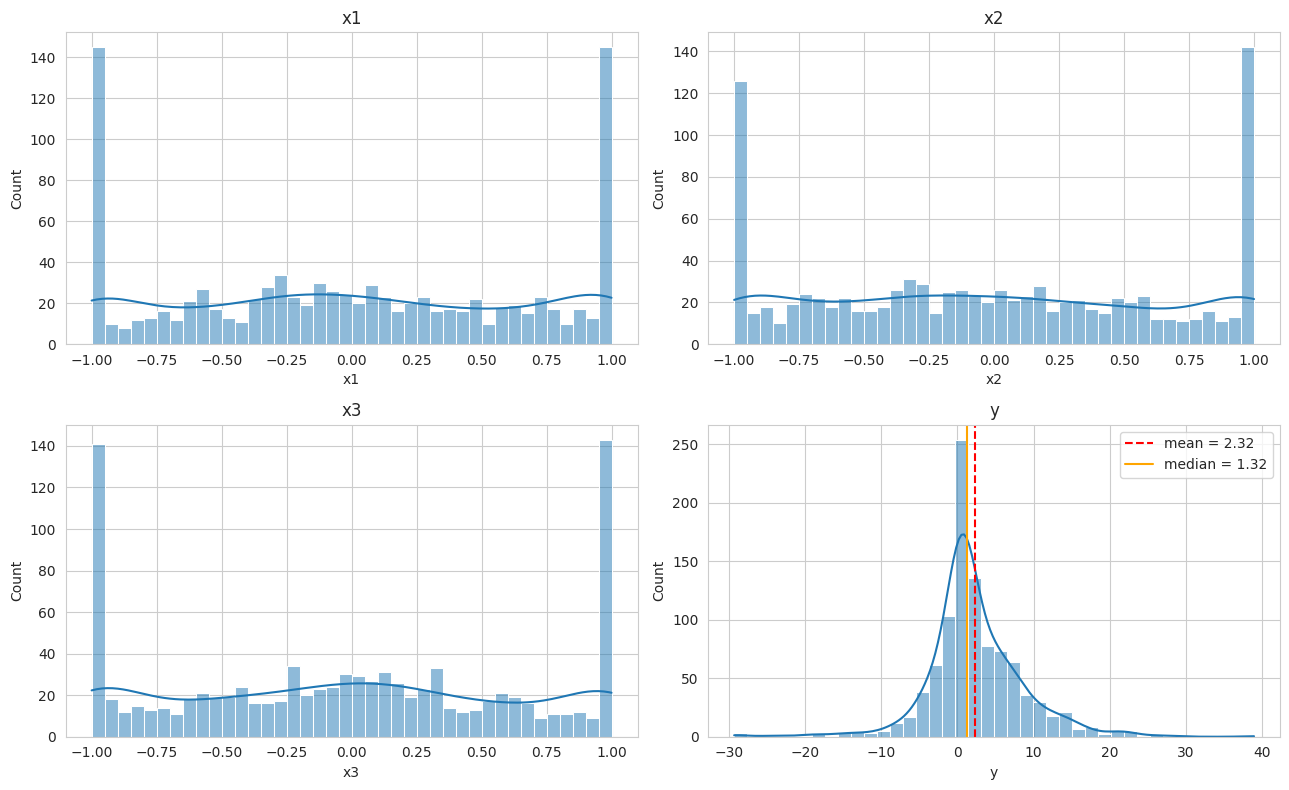

Skewness (train):
x1    0.011
x2    0.077
x3    0.032
y     0.142
dtype: float64

Training rows whose (x1, x2, x3) appears more than once: 6


count    mean    std
x1   x2   x3                        
-1.0 -1.0 -1.0      2   2.575  0.465
 1.0 -1.0 -1.0      2 -29.241  0.124
           1.0      2  -9.450  0.596

Pooled within-group variance of y: 0.195   (overall variance of y: 40.889)


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), features + ['y']):
    sns.histplot(train_df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
axes[1, 1].axvline(train_df['y'].mean(),   color='red',    linestyle='--', label=f"mean = {train_df['y'].mean():.2f}")
axes[1, 1].axvline(train_df['y'].median(), color='orange', linestyle='-',  label=f"median = {train_df['y'].median():.2f}")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

print("Skewness (train):")
print(train_df.skew().round(3))

dup_x = train_df[train_df.duplicated(subset=features, keep=False)]
print(f"\nTraining rows whose (x1, x2, x3) appears more than once: {len(dup_x)}")

groups = dup_x.groupby(features)['y']
display(groups.agg(['count', 'mean', 'std']).sort_values('count', ascending=False).head(10).round(3))

ss  = groups.apply(lambda s: ((s - s.mean()) ** 2).sum()).sum()
dof = (groups.size() - 1).sum()
print(f"Pooled within-group variance of y: {ss / dof:.3f}   (overall variance of y: {train_df['y'].var():.3f})")


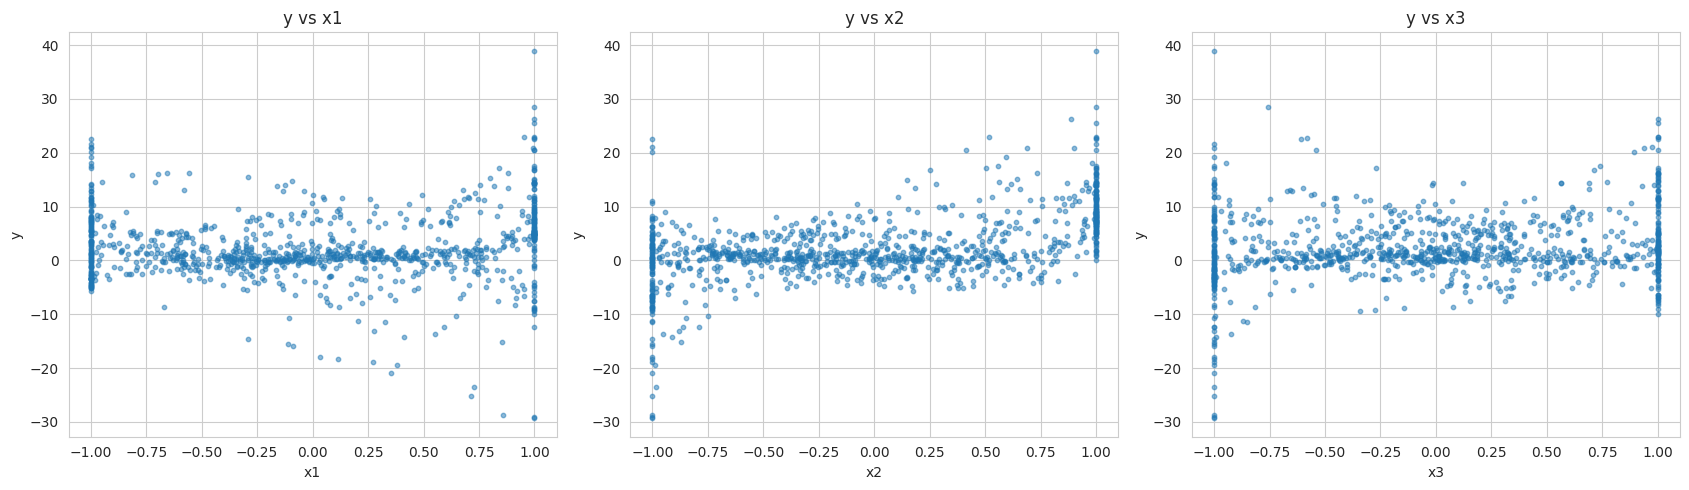

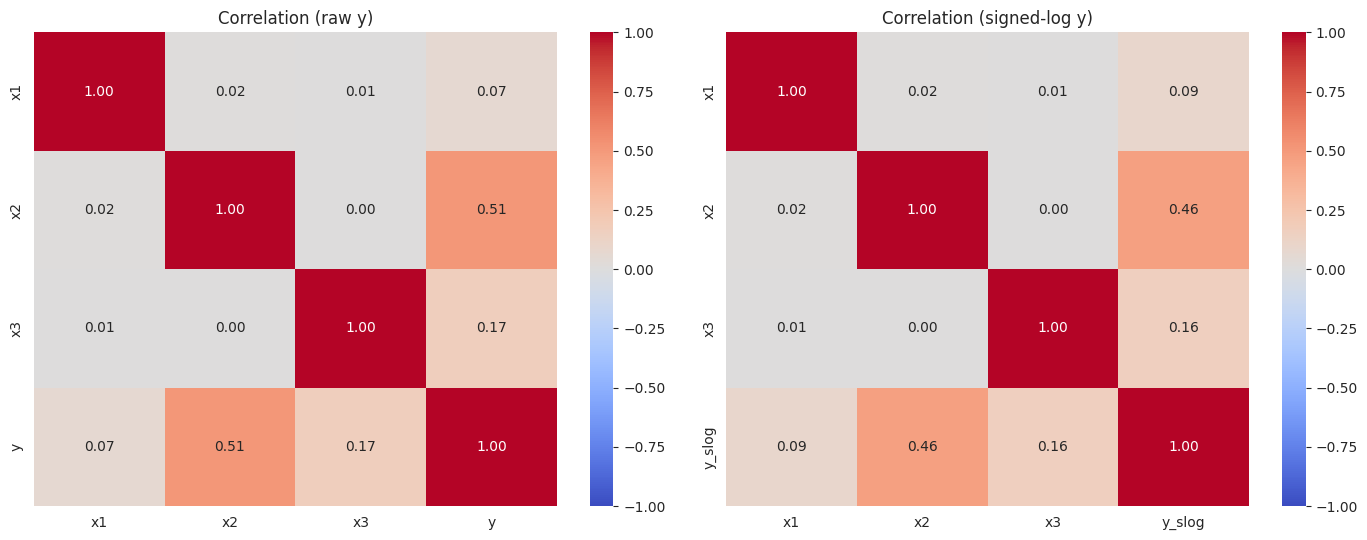

IQR fences for y: [-8.61, 13.42]  ->  83 points outside


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, col in zip(axes, features):
    ax.scatter(train_df[col], train_df['y'], s=10, alpha=0.5)
    ax.set_xlabel(col); ax.set_ylabel('y')
    ax.set_title(f'y vs {col}')
plt.tight_layout()
plt.show()

corr_df = train_df.copy()
corr_df['y_slog'] = np.sign(corr_df['y']) * np.log1p(corr_df['y'].abs())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.heatmap(corr_df[features + ['y']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlation (raw y)')
sns.heatmap(corr_df[features + ['y_slog']].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation (signed-log y)')
plt.tight_layout()
plt.show()

q1, q3 = train_df['y'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
n_out = ((train_df['y'] < low) | (train_df['y'] > high)).sum()
print(f"IQR fences for y: [{low:.2f}, {high:.2f}]  ->  {n_out} points outside")


,train_mean,test_mean,train_std,test_std
x1,0.005,-0.002,0.680,0.672
x2,-0.017,0.009,0.673,0.667
x3,-0.015,-0.010,0.672,0.685


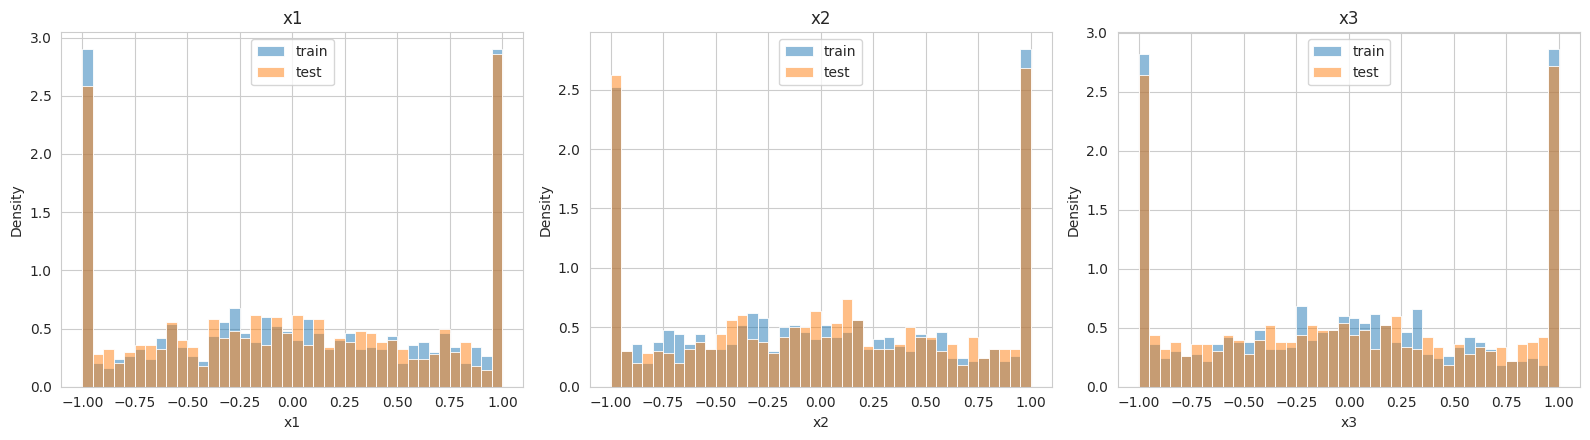

Share of rows by number of clipped features (0 to 3):
   train %  test %
0     41.3    44.4
1     42.5    40.3
2     15.2    14.1
3      1.0     1.2

Max abs difference between train and test feature correlation matrices: 0.017


In [11]:
comparison = pd.DataFrame({
    'train_mean': train_df[features].mean(), 'test_mean': test_df[features].mean(),
    'train_std' : train_df[features].std(),  'test_std' : test_df[features].std(),
})
display(comparison.round(3))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, features):
    sns.histplot(train_df[col], bins=40, stat='density', color='tab:blue',   alpha=0.5, label='train', ax=ax)
    sns.histplot(test_df[col],  bins=40, stat='density', color='tab:orange', alpha=0.5, label='test',  ax=ax)
    ax.set_title(col); ax.legend()
plt.tight_layout()
plt.show()

clip_tr = (train_df[features].abs() == 1).sum(axis=1)
clip_te = (test_df[features].abs()  == 1).sum(axis=1)
print("Share of rows by number of clipped features (0 to 3):")
print(pd.DataFrame({'train %': 100 * clip_tr.value_counts(normalize=True).sort_index(),
                    'test %' : 100 * clip_te.value_counts(normalize=True).sort_index()}).round(1))

max_diff = (train_df[features].corr() - test_df[features].corr()).abs().max().max()
print("\nMax abs difference between train and test feature correlation matrices:",
      round(max_diff, 3))

In [12]:
from itertools import combinations_with_replacement
from math import comb

train_df['y_log'] = np.sign(train_df['y']) * np.log1p(train_df['y'].abs())

def slog_inv(z):
    """Exact inverse of the signed log; clamp only guards against overflow on absurd predictions."""
    z = z.clamp(-8, 8)
    return torch.sign(z) * torch.expm1(z.abs())

X_train_raw = torch.tensor(train_df[features].values, dtype=torch.float64)
y_train     = torch.tensor(train_df['y'].values,      dtype=torch.float64).reshape(-1, 1)
y_train_log = torch.tensor(train_df['y_log'].values,  dtype=torch.float64).reshape(-1, 1)
X_test_raw  = torch.tensor(test_df[features].values,  dtype=torch.float64)

print("y      : mean %.3f  std %.3f  min %.3f  max %.3f" % (y_train.mean(), y_train.std(), y_train.min(), y_train.max()))
print("y_log  : mean %.3f  std %.3f  min %.3f  max %.3f" % (y_train_log.mean(), y_train_log.std(), y_train_log.min(), y_train_log.max()))
print("max |inverse(y_log) - y| =", (slog_inv(y_train_log) - y_train).abs().max().item())

def poly_features(X, degree):
    """All monomials of total degree 1..degree (no constant column)."""
    n, d = X.shape
    cols = []
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            cols.append(X[:, list(combo)].prod(dim=1))
    return torch.stack(cols, dim=1)

print("\n", poly_features(torch.tensor([[1., 2., 3.]], dtype=torch.float64), 2))

for d in [1, 2, 5, 10, 20]:
    out = poly_features(X_train_raw, d)
    print(f"degree {d:2d}: shape {tuple(out.shape)}  formula: {comb(d + 3, 3) - 1}")


y      : mean 2.319  std 6.394  min -29.328  max 38.966
y_log  : mean 0.648  std 1.460  min -3.412  max 3.688
max |inverse(y_log) - y| = 3.552713678800501e-15

 tensor([[1., 2., 3., 1., 2., 3., 4., 6., 9.]], dtype=torch.float64)
degree  1: shape (1000, 3)  formula: 3
degree  2: shape (1000, 9)  formula: 9
degree  5: shape (1000, 55)  formula: 55
degree 10: shape (1000, 285)  formula: 285
degree 20: shape (1000, 1770)  formula: 1770


In [13]:
from sklearn.preprocessing import StandardScaler

deg = 10
F_all  = poly_features(X_train_raw, deg)
F_test = poly_features(X_test_raw,  deg)

stats = pd.DataFrame({
    'mean': F_all.mean(dim=0).numpy(),
    'std' : F_all.std(dim=0).numpy(),
    'min' : F_all.min(dim=0).values.numpy(),
    'max' : F_all.max(dim=0).values.numpy(),
})
print(f"Degree {deg}, BEFORE scaling: summary across the {F_all.shape[1]} columns")
display(stats.describe().T)

print("\nColumn std (min / median / max) and max:min ratio, by degree:")
for d in [1, 5, 10, 20]:
    s = poly_features(X_train_raw, d).std(dim=0)
    print(f"  degree {d:2d}: {s.min():.4f} / {s.median():.4f} / {s.max():.4f}   ratio {(s.max()/s.min()):.1f}x")

scaler = StandardScaler()
F_scaled      = torch.tensor(scaler.fit_transform(F_all.numpy()))
F_test_scaled = torch.tensor(scaler.transform(F_test.numpy()))

print(f"\nAFTER scaling (train): max |column mean| = {F_scaled.mean(dim=0).abs().max().item():.2e}")
print(f"AFTER scaling (train): column std min/max = {F_scaled.std(dim=0).min().item():.4f} / {F_scaled.std(dim=0).max().item():.4f}")
print(f"AFTER scaling (test, train stats): max |column mean| = {F_test_scaled.mean(dim=0).abs().max().item():.3f}")
print(f"AFTER scaling (test, train stats): column std min/max = {F_test_scaled.std(dim=0).min().item():.3f} / {F_test_scaled.std(dim=0).max().item():.3f}")


Degree 10, BEFORE scaling: summary across the 285 columns


,count,mean,std,min,25%,50%,75%,max
mean,285.0,0.037498,0.089044,-0.016606,-0.001727,0.002645,0.011685,4.625441e-01
std,285.0,0.294193,0.102470,0.152518,0.205606,0.290992,0.354607,6.804313e-01
min,285.0,-0.807018,0.395334,-1.000000,-1.000000,-1.000000,-1.000000,6.350288e-07
max,285.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00



Column std (min / median / max) and max:min ratio, by degree:
  degree  1: 0.6718 / 0.6733 / 0.6804   ratio 1.0x
  degree  5: 0.2303 / 0.3850 / 0.6804   ratio 3.0x
  degree 10: 0.1525 / 0.2910 / 0.6804   ratio 4.5x
  degree 20: 0.1221 / 0.1839 / 0.6804   ratio 5.6x

AFTER scaling (train): max |column mean| = 1.31e-15
AFTER scaling (train): column std min/max = 1.0005 / 1.0005
AFTER scaling (test, train stats): max |column mean| = 0.104
AFTER scaling (test, train stats): column std min/max = 0.913 / 1.144


# Model Selection

Target: log | baseline (predict the mean) MSE ~ 40.89



model,Lasso,Least squares,Ridge
degree,,,
1,31.369,31.369,31.369
2,25.904,41.976,26.950
3,14.208,17.323,14.321
4,6.722,19.067,7.167
5,6.819,10.486,5.873
6,5.852,10.502,5.338
7,7.237,9.306,4.732
8,3.118,4.686,2.855
9,2.706,3.897,3.049



Best overall CV MSE: 1.6211
Lowest degree within 2% of the best: degree 10, Lasso, lambda 1.08e-04, CV MSE 1.6211 (+/- 1.0159), CV R2 0.9604


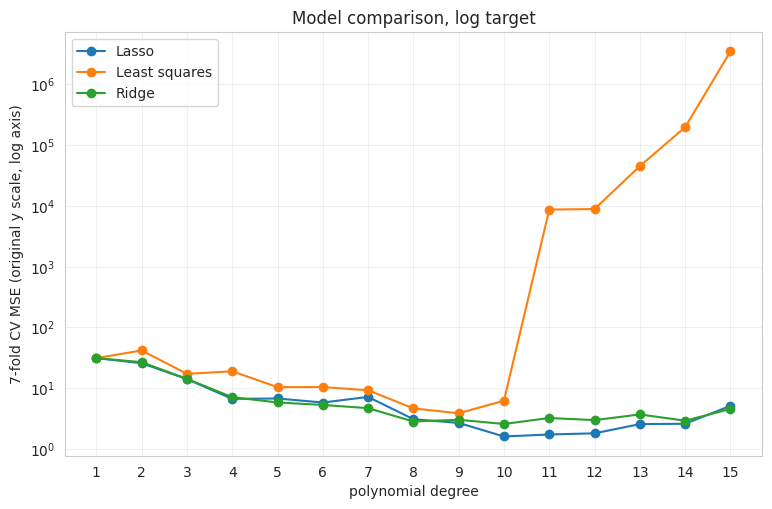

In [15]:
import warnings
from math import comb
from sklearn.linear_model import lasso_path
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

TARGET = 'log'
K = 7
degrees      = list(range(1, 16))
ridge_lams   = np.logspace(-6, 1, 29)
lasso_alphas = np.logspace(0, -5, 30)

identity = lambda t: t
y_fit, inverse = (y_train_log, slog_inv) if TARGET == 'log' else (y_train, identity)

F_cmp  = poly_features(X_train_raw, max(degrees))
n_cols = {d: comb(d + 3, 3) - 1 for d in degrees}
n = X_train_raw.shape[0]
g = torch.Generator().manual_seed(RANDOM_SEED)
folds = torch.chunk(torch.randperm(n, generator=g), K)

ls_sc    = np.zeros((len(degrees), K))
ridge_sc = np.zeros((len(degrees), len(ridge_lams),   K))
lasso_sc = np.zeros((len(degrees), len(lasso_alphas), K))

for f in range(K):
    va = folds[f]
    tr = torch.cat([folds[j] for j in range(K) if j != f])
    sc  = StandardScaler()
    Ftr = torch.tensor(sc.fit_transform(F_cmp[tr].numpy()))
    Fva = torch.tensor(sc.transform(F_cmp[va].numpy()))
    ytr, yva = y_fit[tr], y_train[va]
    mu, n_tr = ytr.mean(), Ftr.shape[0]
    yc = ytr - mu

    for i, d in enumerate(degrees):
        A, B = Ftr[:, :n_cols[d]], Fva[:, :n_cols[d]]

        w_ls = np.linalg.lstsq(A.numpy(), yc.numpy().ravel(), rcond=None)[0]
        pred = torch.tensor(B.numpy() @ w_ls + mu.item()).reshape(-1, 1)
        ls_sc[i, f] = ((yva - inverse(pred)) ** 2).mean().item()

        e, U = torch.linalg.eigh(A @ A.T)
        Uty, Kva = U.T @ yc, B @ A.T
        for j, lam in enumerate(ridge_lams):
            alpha = U @ (Uty / (e.unsqueeze(1) + n_tr * lam))
            ridge_sc[i, j, f] = ((yva - inverse(Kva @ alpha + mu)) ** 2).mean().item()

        _, coefs, _ = lasso_path(A.numpy(), yc.numpy().ravel(), alphas=lasso_alphas, max_iter=20000)
        pred = torch.tensor(B.numpy() @ coefs + mu.item())
        lasso_sc[i, :, f] = ((yva - inverse(pred)) ** 2).mean(dim=0).numpy()

rows = []
for i, d in enumerate(degrees):
    rows.append(dict(degree=d, model='Least squares', lam=0.0,
                     cv_mse=ls_sc[i].mean(), cv_std=ls_sc[i].std()))
    j = ridge_sc[i].mean(axis=1).argmin()
    rows.append(dict(degree=d, model='Ridge', lam=ridge_lams[j],
                     cv_mse=ridge_sc[i, j].mean(), cv_std=ridge_sc[i, j].std()))
    a = lasso_sc[i].mean(axis=1).argmin()
    rows.append(dict(degree=d, model='Lasso', lam=lasso_alphas[a],
                     cv_mse=lasso_sc[i, a].mean(), cv_std=lasso_sc[i, a].std()))
res = pd.DataFrame(rows)
res['cv_r2'] = 1 - res.cv_mse / y_train.var().item()

print(f"Target: {TARGET} | baseline (predict the mean) MSE ~ {y_train.var().item():.2f}\n")
display(res.pivot(index='degree', columns='model', values='cv_mse').round(3))

best = res.cv_mse.min()
pick = res[res.cv_mse <= 1.02 * best].sort_values(['degree', 'cv_mse']).iloc[0]
print(f"\nBest overall CV MSE: {best:.4f}")
print(f"Lowest degree within 2% of the best: degree {int(pick.degree)}, {pick.model}, "
      f"lambda {pick.lam:.2e}, CV MSE {pick.cv_mse:.4f} (+/- {pick.cv_std:.4f}), CV R2 {pick.cv_r2:.4f}")

plt.figure(figsize=(9, 5.5))
for name, gg in res.groupby('model'):
    plt.plot(gg.degree, gg.cv_mse, marker='o', label=name)
plt.yscale('log'); plt.xticks(degrees)
plt.xlabel('polynomial degree'); plt.ylabel(f'{K}-fold CV MSE (original y scale, log axis)')
plt.title(f'Model comparison, {TARGET} target'); plt.legend(); plt.grid(alpha=0.3)
plt.show()


Target: raw | baseline (predict the mean) MSE ~ 40.89



model,Lasso,Least squares,Ridge
degree,,,
1,29.134,29.134,29.133
2,19.711,19.711,19.710
3,10.577,10.578,10.577
4,3.516,3.516,3.516
5,1.404,1.404,1.403
6,0.559,0.559,0.559
7,0.342,0.343,0.342
8,0.254,0.255,0.254
9,0.253,0.279,0.256



Best overall CV MSE: 0.2415
Lowest degree within 2% of the best: degree 10, Lasso, lambda 3.56e-04, CV MSE 0.2415 (+/- 0.0141), CV R2 0.9941


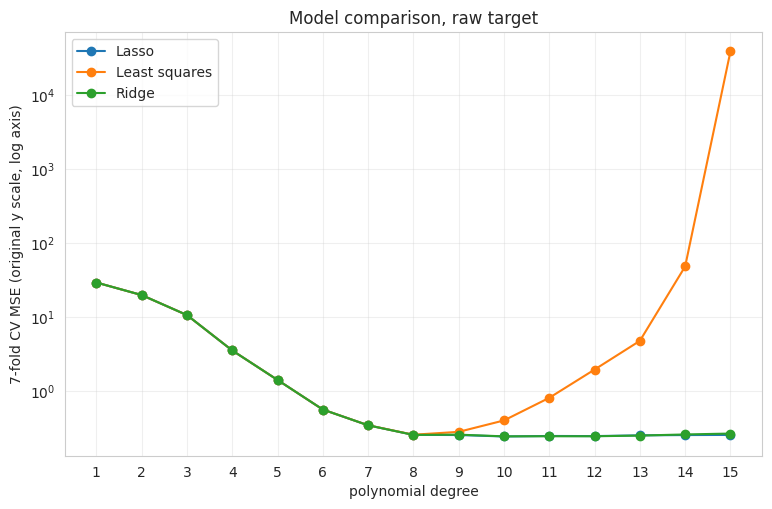

In [16]:
import warnings
from math import comb
from sklearn.linear_model import lasso_path
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

TARGET = 'raw'
K = 7
degrees      = list(range(1, 16))
ridge_lams   = np.logspace(-6, 1, 29)
lasso_alphas = np.logspace(0, -5, 30)

identity = lambda t: t
y_fit, inverse = (y_train_log, slog_inv) if TARGET == 'log' else (y_train, identity)

F_cmp  = poly_features(X_train_raw, max(degrees))
n_cols = {d: comb(d + 3, 3) - 1 for d in degrees}
n = X_train_raw.shape[0]
g = torch.Generator().manual_seed(RANDOM_SEED)
folds = torch.chunk(torch.randperm(n, generator=g), K)

ls_sc    = np.zeros((len(degrees), K))
ridge_sc = np.zeros((len(degrees), len(ridge_lams),   K))
lasso_sc = np.zeros((len(degrees), len(lasso_alphas), K))

for f in range(K):
    va = folds[f]
    tr = torch.cat([folds[j] for j in range(K) if j != f])
    sc  = StandardScaler()
    Ftr = torch.tensor(sc.fit_transform(F_cmp[tr].numpy()))
    Fva = torch.tensor(sc.transform(F_cmp[va].numpy()))
    ytr, yva = y_fit[tr], y_train[va]
    mu, n_tr = ytr.mean(), Ftr.shape[0]
    yc = ytr - mu

    for i, d in enumerate(degrees):
        A, B = Ftr[:, :n_cols[d]], Fva[:, :n_cols[d]]

        w_ls = np.linalg.lstsq(A.numpy(), yc.numpy().ravel(), rcond=None)[0]
        pred = torch.tensor(B.numpy() @ w_ls + mu.item()).reshape(-1, 1)
        ls_sc[i, f] = ((yva - inverse(pred)) ** 2).mean().item()

        e, U = torch.linalg.eigh(A @ A.T)
        Uty, Kva = U.T @ yc, B @ A.T
        for j, lam in enumerate(ridge_lams):
            alpha = U @ (Uty / (e.unsqueeze(1) + n_tr * lam))
            ridge_sc[i, j, f] = ((yva - inverse(Kva @ alpha + mu)) ** 2).mean().item()

        _, coefs, _ = lasso_path(A.numpy(), yc.numpy().ravel(), alphas=lasso_alphas, max_iter=20000)
        pred = torch.tensor(B.numpy() @ coefs + mu.item())
        lasso_sc[i, :, f] = ((yva - inverse(pred)) ** 2).mean(dim=0).numpy()

rows = []
for i, d in enumerate(degrees):
    rows.append(dict(degree=d, model='Least squares', lam=0.0,
                     cv_mse=ls_sc[i].mean(), cv_std=ls_sc[i].std()))
    j = ridge_sc[i].mean(axis=1).argmin()
    rows.append(dict(degree=d, model='Ridge', lam=ridge_lams[j],
                     cv_mse=ridge_sc[i, j].mean(), cv_std=ridge_sc[i, j].std()))
    a = lasso_sc[i].mean(axis=1).argmin()
    rows.append(dict(degree=d, model='Lasso', lam=lasso_alphas[a],
                     cv_mse=lasso_sc[i, a].mean(), cv_std=lasso_sc[i, a].std()))
res = pd.DataFrame(rows)
res['cv_r2'] = 1 - res.cv_mse / y_train.var().item()

print(f"Target: {TARGET} | baseline (predict the mean) MSE ~ {y_train.var().item():.2f}\n")
display(res.pivot(index='degree', columns='model', values='cv_mse').round(3))

best = res.cv_mse.min()
pick = res[res.cv_mse <= 1.02 * best].sort_values(['degree', 'cv_mse']).iloc[0]
print(f"\nBest overall CV MSE: {best:.4f}")
print(f"Lowest degree within 2% of the best: degree {int(pick.degree)}, {pick.model}, "
      f"lambda {pick.lam:.2e}, CV MSE {pick.cv_mse:.4f} (+/- {pick.cv_std:.4f}), CV R2 {pick.cv_r2:.4f}")

plt.figure(figsize=(9, 5.5))
for name, gg in res.groupby('model'):
    plt.plot(gg.degree, gg.cv_mse, marker='o', label=name)
plt.yscale('log'); plt.xticks(degrees)
plt.xlabel('polynomial degree'); plt.ylabel(f'{K}-fold CV MSE (original y scale, log axis)')
plt.title(f'Model comparison, {TARGET} target'); plt.legend(); plt.grid(alpha=0.3)
plt.show()


Baseline MSE ~ 40.89

degree  cols | best lambda |   CV MSE     std      R2
     1     3 |    7.50e-03 |  29.2210  7.3886  0.2854
     2     9 |    7.50e-03 |  19.8382  4.8847  0.5148
     3    19 |    7.50e-04 |  10.5196  2.0848  0.7427
     4    34 |    1.00e-06 |   3.4793  0.7231  0.9149
     5    55 |    5.62e-05 |   1.4385  0.5272  0.9648
     6    83 |    1.00e-06 |   0.5521  0.1083  0.9865
     7   119 |    1.00e-06 |   0.3472  0.0886  0.9915
     8   164 |    5.62e-06 |   0.2609  0.0404  0.9936
     9   219 |    4.22e-04 |   0.2792  0.0947  0.9932
    10   285 |    1.33e-03 |   0.2562  0.0650  0.9937
    11   363 |    2.37e-03 |   0.2659  0.1075  0.9935
    12   454 |    3.16e-03 |   0.2588  0.0841  0.9937
    13   559 |    4.22e-03 |   0.2740  0.1313  0.9933
    14   679 |    5.62e-03 |   0.2764  0.1079  0.9932
    15   815 |    5.62e-03 |   0.2941  0.1501  0.9928
    16   968 |    7.50e-03 |   0.3050  0.1405  0.9925
    17  1139 |    5.62e-03 |   0.3215  0.1608  0.9921
    18

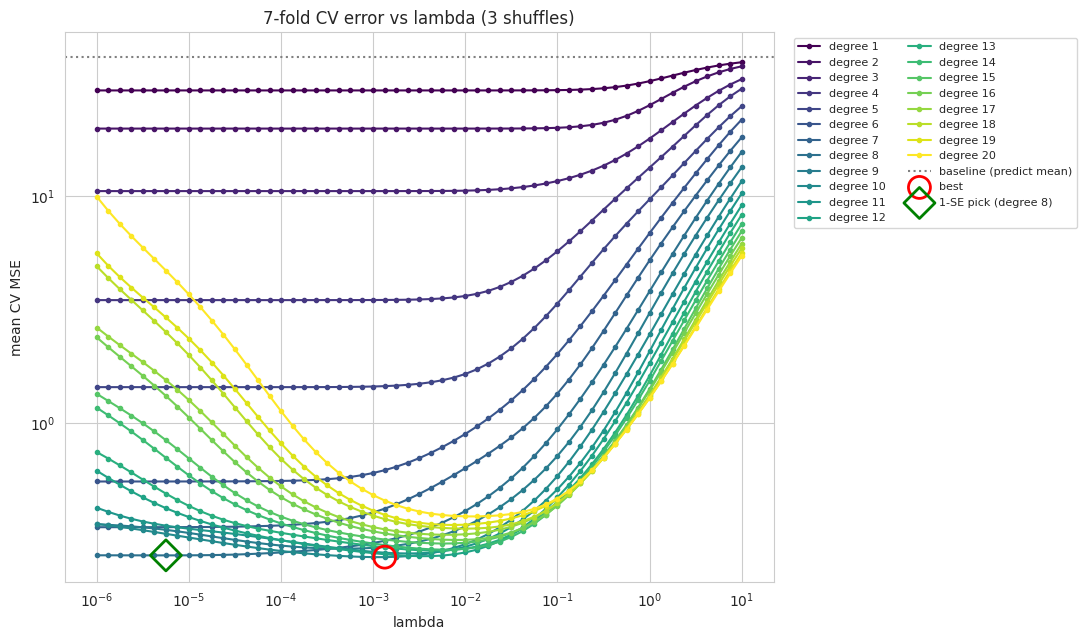

In [18]:
K = 7
SEEDS   = (42, 43, 44)
degrees = list(range(1, 21))
lams    = [float(l) for l in np.logspace(-6, 1, 57)]

F_full = poly_features(X_train_raw, 20)
n_cols = {d: comb(d + 3, 3) - 1 for d in degrees}
n = X_train_raw.shape[0]

scores = torch.zeros(len(degrees), len(lams), K * len(SEEDS), dtype=torch.float64)
s = 0
for seed in SEEDS:
    g = torch.Generator().manual_seed(seed)
    folds = torch.chunk(torch.randperm(n, generator=g), K)
    for f in range(K):
        va = folds[f]
        tr = torch.cat([folds[j] for j in range(K) if j != f])

        sc  = StandardScaler()
        Ftr = torch.tensor(sc.fit_transform(F_full[tr].numpy()))
        Fva = torch.tensor(sc.transform(F_full[va].numpy()))
        ytr, yva = y_train[tr], y_train[va]
        mu, n_tr = ytr.mean(), Ftr.shape[0]
        yc = ytr - mu

        for i, d in enumerate(degrees):
            A, B = Ftr[:, :n_cols[d]], Fva[:, :n_cols[d]]
            e, U = torch.linalg.eigh(A @ A.T)
            Uty, Kva = U.T @ yc, B @ A.T
            for j, lam in enumerate(lams):
                alpha = U @ (Uty / (e.unsqueeze(1) + n_tr * lam))
                scores[i, j, s] = ((yva - (Kva @ alpha + mu)) ** 2).mean()
        s += 1

cv_mean = scores.mean(dim=2)
jbest   = cv_mean.argmin(dim=1)
best_mse = torch.stack([cv_mean[i, jbest[i]] for i in range(len(degrees))])
best_std = torch.stack([scores[i, jbest[i]].std() for i in range(len(degrees))])
best_se  = best_std / np.sqrt(K)

print(f"Baseline MSE ~ {y_train.var().item():.2f}\n")
print(f"{'degree':>6} {'cols':>5} | {'best lambda':>11} | {'CV MSE':>8} {'std':>7} {'R2':>7}")
for i, d in enumerate(degrees):
    print(f"{d:6d} {n_cols[d]:5d} | {lams[jbest[i]]:11.2e} | {best_mse[i]:8.4f} {best_std[i]:7.4f} "
          f"{1 - best_mse[i] / y_train.var().item():7.4f}")

istar = best_mse.argmin().item()
pick_se = next(i for i in range(len(degrees)) if best_mse[i] <= best_mse[istar] + best_se[istar])
pick_2  = next(i for i in range(len(degrees)) if best_mse[i] <= 1.02 * best_mse[istar])
print(f"\nBest overall: degree {degrees[istar]}, lambda {lams[jbest[istar]]:.2e}, CV MSE {best_mse[istar]:.4f}")
print(f"Lowest degree within 1 standard error: degree {degrees[pick_se]} (lambda {lams[jbest[pick_se]]:.2e}, MSE {best_mse[pick_se]:.4f})")
print(f"Lowest degree within 2%:               degree {degrees[pick_2]} (lambda {lams[jbest[pick_2]]:.2e}, MSE {best_mse[pick_2]:.4f})")

plt.figure(figsize=(11, 6.5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(degrees)))

for i, d in enumerate(degrees):
    plt.plot(lams, cv_mean[i].numpy(), marker='o', markersize=3, color=cmap[i], label=f'degree {d}')

plt.axhline(y_train.var().item(), color='gray', linestyle=':', label='baseline (predict mean)')
plt.scatter(lams[jbest[istar]], best_mse[istar].item(), s=250, facecolors='none',
            edgecolors='red', linewidths=2, zorder=5, label='best')
plt.scatter(lams[jbest[pick_se]], best_mse[pick_se].item(), s=250, marker='D', facecolors='none',
            edgecolors='green', linewidths=2, zorder=5, label=f'1-SE pick (degree {degrees[pick_se]})')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('lambda'); plt.ylabel('mean CV MSE')
plt.title(f'{K}-fold CV error vs lambda ({len(SEEDS)} shuffles)')
plt.legend(fontsize=8, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [19]:
i8 = degrees.index(8)
thr = cv_mean[i8].min() + best_se[i8]
lam_choice = max(l for l, m in zip(lams, cv_mean[i8]) if m <= thr)
print(f"degree 8: min CV MSE {cv_mean[i8].min():.4f}, threshold {thr:.4f}")
print(f"largest lambda within 1 SE: {lam_choice:.2e}  (CV MSE {cv_mean[i8][lams.index(lam_choice)]:.4f})")

degree 8: min CV MSE 0.2609, threshold 0.2761
largest lambda within 1 SE: 2.37e-04  (CV MSE 0.2755)


In [20]:
print("degree 8: CV MSE vs lambda")
for k, (l, m) in enumerate(zip(lams, cv_mean[i8])):
    if k % 4 == 0 and l <= 1e-2:
        print(f"  {l:9.2e}   {m:.4f}")

lam_1pct = max(l for l, m in zip(lams, cv_mean[i8]) if m <= 1.01 * cv_mean[i8].min())
print(f"\nlargest lambda within 1% of the best: {lam_1pct:.2e}  "
      f"(CV MSE {cv_mean[i8][lams.index(lam_1pct)]:.4f})")


degree 8: CV MSE vs lambda
   1.00e-06   0.2611
   3.16e-06   0.2609
   1.00e-05   0.2610
   3.16e-05   0.2630
   1.00e-04   0.2687
   3.16e-04   0.2784
   1.00e-03   0.2959
   3.16e-03   0.3320
   1.00e-02   0.4094

largest lambda within 1% of the best: 3.16e-05  (CV MSE 0.2630)


In [21]:
DEG = 10
LAM = 10 ** -2.875

def ridge_train(F, y, lam):
    """Closed-form ridge on scaled features. Returns weights w and intercept b (bias not penalised)."""
    m, p = F.shape
    F_mu, y_mu = F.mean(dim=0, keepdim=True), y.mean()
    Fc, yc = F - F_mu, y - y_mu
    w = torch.linalg.solve(Fc.T @ Fc / m + lam * torch.eye(p, dtype=F.dtype), Fc.T @ yc / m)
    return w, y_mu - F_mu @ w

F_tr = poly_features(X_train_raw, DEG)
F_te = poly_features(X_test_raw,  DEG)

scaler = StandardScaler()
F_tr_s = torch.tensor(scaler.fit_transform(F_tr.numpy()))
F_te_s = torch.tensor(scaler.transform(F_te.numpy()))

w, b = ridge_train(F_tr_s, y_train, LAM)
train_pred = F_tr_s @ w + b
test_pred  = F_te_s @ w + b

train_mse = ((y_train - train_pred) ** 2).mean().item()
train_r2  = 1 - ((y_train - train_pred) ** 2).sum().item() / ((y_train - y_train.mean()) ** 2).sum().item()

i10 = degrees.index(DEG)
j10 = min(range(len(lams)), key=lambda k: abs(lams[k] - LAM))
print(f"{F_tr.shape[1]} terms, lambda {LAM:.2e}")
print(f"Train MSE {train_mse:.4f}  R2 {train_r2:.4f}  |  CV MSE estimate {cv_mean[i10][j10]:.4f}")

print("\nTest predictions vs training y:")
print(pd.DataFrame({'train y': y_train.flatten().numpy(),
                    'test pred': test_pred.flatten().numpy()}).describe().T.round(3))


285 terms, lambda 1.33e-03
Train MSE 0.1709  R2 0.9958  |  CV MSE estimate 0.2562

Test predictions vs training y:
            count   mean    std     min    25%    50%    75%     max
train y    1000.0  2.319  6.394 -29.328 -0.352  1.324  5.156  38.966
test pred  1000.0  2.429  6.509 -29.188 -0.559  1.189  5.208  38.836


In [22]:
out = test_df.copy()
out['y'] = test_pred.flatten().numpy()
out.to_csv('BT2024238_pred_var2.csv', index=False)

chk = pd.read_csv('BT2024238_pred_var2.csv')
print("shape:", chk.shape, "| columns:", chk.columns.tolist())
print("NaNs:", chk.isna().sum().sum())
print("same inputs as the test file:", (chk[features].values == test_df[features].values).all())
chk.head()

shape: (1000, 4) | columns: ['x1', 'x2', 'x3', 'y']
NaNs: 0
same inputs as the test file: True


,x1,x2,x3,y
0,-0.356194,-0.403324,0.849142,0.197472
1,0.785525,-0.700827,0.259012,1.042838
2,-0.658955,-0.058534,0.997535,1.902759
3,0.266473,-1.000000,-0.498258,-1.191028
4,0.035658,-0.095934,1.000000,-0.384806
